In [3]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scipy.sparse as sp
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, accuracy_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier
SEED = 42
TARGET, ID = 'h1n1_vaccine', 'respondent_id'
pd.set_option('display.max_columns', None)

In [5]:
# Load the data

In [9]:
train  = pd.read_csv('dataset_B_training.csv')
test   = pd.read_csv('dataset_B_testing.csv')
sample = pd.read_csv('/content/dataset_B_training.csv')
print('train:', train.shape, '  test:', test.shape)
train.head()

train: (4756, 31)   test: (4749, 30)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,h1n1_vaccine
0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,4.0,4.0,1.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,science,0
1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,1.0,2.0,18 - 34 Years,Some College,White,Female,Below Poverty,Not Married,Own,Employed,Non-MSA,0.0,3.0,wholesale,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0,1.0,3.0,4.0,2.0,45 - 54 Years,College Graduate,White,Female,"> $75,000",Not Married,Own,Employed,"MSA, Principle City",0.0,0.0,education,1
3,4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,4.0,18 - 34 Years,College Graduate,White,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,Non-MSA,0.0,0.0,NaN,0
4,5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,2.0,2.0,1.0,18 - 34 Years,< 12 Years,White,Female,NaN,Not Married,NaN,Unemployed,Non-MSA,3.0,0.0,NaN,0


employment_sector              49.7
health_insurance               40.5
income_poverty                 15.0
doctor_recc_h1n1                6.7
rent_or_own                     6.6
employment_status               4.9
marital_status                  4.8
education                       4.7
chronic_med_condition           3.4
health_worker                   2.8
child_under_6_months            2.8
opinion_h1n1_vacc_effective     1.5
opinion_h1n1_sick_from_vacc     1.3
opinion_h1n1_risk               1.3
household_adults                0.7
household_children              0.7
behavioral_avoidance            0.6
h1n1_knowledge                  0.5
behavioral_antiviral_meds       0.4
behavioral_touch_face           0.4
h1n1_concern                    0.3
behavioral_outside_home         0.3
behavioral_large_gatherings     0.2
behavioral_wash_hands           0.2
behavioral_face_mask            0.1
dtype: float64


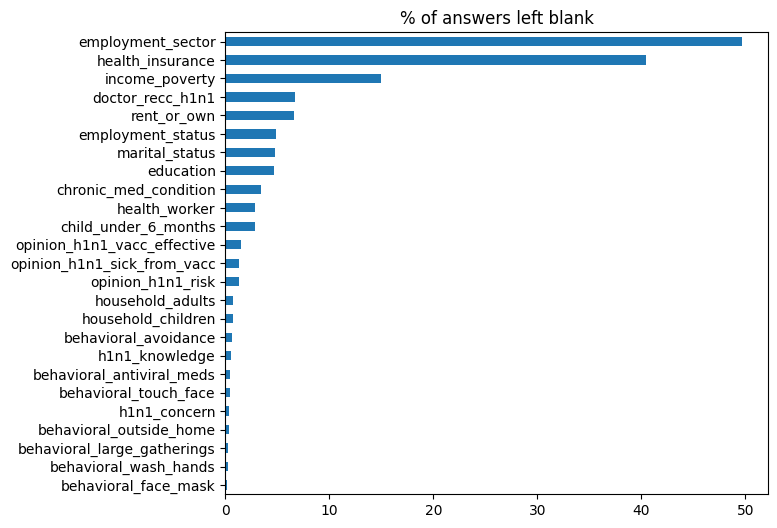

In [10]:
gaps = (train.isna().mean()*100).round(1); gaps = gaps[gaps>0].sort_values(ascending=False)
print(gaps)
gaps.plot(kind='barh', figsize=(7,6), title='% of answers left blank'); plt.gca().invert_yaxis(); plt.show()

doctor_recc_h1n1               0.413874
opinion_h1n1_risk              0.362183
opinion_h1n1_vacc_effective    0.325057
health_worker                  0.205428
h1n1_knowledge                 0.148766
h1n1_concern                   0.143235
health_insurance               0.129246
chronic_med_condition          0.107138
behavioral_touch_face          0.103222
behavioral_wash_hands          0.092827
Name: h1n1_vaccine, dtype: float64


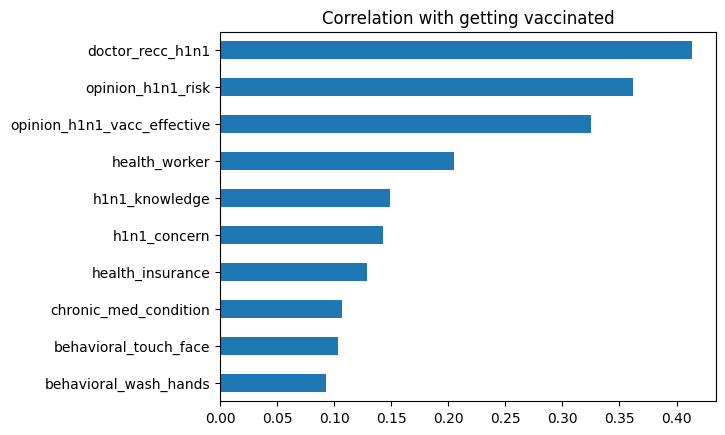

In [11]:
numeric = train.select_dtypes('number').drop(columns=[ID])
signal = numeric.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(signal.head(10))
signal.head(10).plot(kind='barh', title='Correlation with getting vaccinated'); plt.gca().invert_yaxis(); plt.show()

In [12]:
y = train[TARGET].values
X = train.drop(columns=[TARGET, ID]).copy(); X_test = test.drop(columns=[ID]).copy()
text_cols = ['age_group','education','race','sex','income_poverty','marital_status',
             'rent_or_own','employment_status','census_msa','employment_sector']
target_enc_cols = ['employment_sector']
onehot_cols = [c for c in text_cols if c not in target_enc_cols]
base_num    = [c for c in X.columns if c not in text_cols]
for df in (X, X_test):
    for c in text_cols: df[c] = df[c].fillna('Missing').astype(str)
precautions = ['behavioral_antiviral_meds','behavioral_avoidance','behavioral_face_mask','behavioral_wash_hands',
               'behavioral_large_gatherings','behavioral_outside_home','behavioral_touch_face']
for df in (X, X_test):
    df['behavioral_count'] = df[precautions].sum(axis=1)
    df['doc_x_risk'] = df['doctor_recc_h1n1'].fillna(0) * df['opinion_h1n1_risk'].fillna(0)
eng_num = ['behavioral_count','doc_x_risk']
print('one-hot text:', len(onehot_cols), ' target-encoded:', target_enc_cols)

one-hot text: 9  target-encoded: ['employment_sector']


In [13]:
def encode_sector(fit_values, fit_labels, apply_values, m=20.0):
    overall = fit_labels.mean()
    tbl = pd.DataFrame({'sector': fit_values.values, 'y': fit_labels})
    stats = tbl.groupby('sector')['y'].agg(['mean','count'])
    smoothed = (stats['mean']*stats['count'] + overall*m) / (stats['count'] + m)
    return apply_values.map(smoothed).fillna(overall).values

In [14]:
num_cols = base_num + eng_num + ['emp_sector_te']
def make_preprocessor(impute, scale):
    steps = []
    if impute: steps.append(('impute', SimpleImputer(strategy='median')))
    if scale:  steps.append(('scale', StandardScaler()))
    numeric = Pipeline(steps) if steps else 'passthrough'
    return ColumnTransformer([('num', numeric, num_cols),
                              ('cat', OneHotEncoder(handle_unknown='ignore'), onehot_cols)])

def logreg():       return Pipeline([('prep', make_preprocessor(True, True)),
                                     ('model', LogisticRegression(max_iter=3000, C=0.5))])
def random_forest():return Pipeline([('prep', make_preprocessor(True, False)),
                                     ('model', RandomForestClassifier(n_estimators=600, min_samples_leaf=5,
                                               max_features='sqrt', n_jobs=-1, random_state=SEED))])
def hist_gbm():     return Pipeline([('prep', make_preprocessor(False, False)),
                                     ('model', HistGradientBoostingClassifier(learning_rate=0.03, max_iter=800,
                                               max_leaf_nodes=31, min_samples_leaf=40, l2_regularization=2.0,
                                               early_stopping=True, validation_fraction=0.1, random_state=SEED))])
def light_gbm():    return Pipeline([('prep', make_preprocessor(False, False)),
                                     ('model', LGBMClassifier(n_estimators=700, learning_rate=0.02, num_leaves=31,
                                               min_child_samples=40, subsample=0.8, subsample_freq=1,
                                               colsample_bytree=0.8, reg_lambda=2.0, random_state=SEED, verbose=-1))])
model_builders = {'LogReg': logreg, 'RandomForest': random_forest,
                  'HistGBM': hist_gbm, 'LightGBM': light_gbm}